# 8.1 — Superficie de volatilidad implícita: arbitraje estático y SVI

Arranca M8. La superficie de volatilidad implícita $\sigma(K,T)$ no es un objeto libre:
para que los precios de vainilla que implica sean consistentes con no-arbitraje, debe
satisfacer dos condiciones estructurales (calendario y butterfly). La parametrización
**SVI** (Gatheral, 2004) da una forma funcional de 5 parámetros por vencimiento que, con
las restricciones adecuadas, es fácil de mantener arbitrage-free y de calibrar a
mercado.

## 0. Configuración

In [1]:
import numpy as np
from scipy.optimize import least_squares
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401 (registra el proyector 3d)

from qflib.market import svi_total_variance
from qflib.black import bs_price, implied_vol
from qflib.plotting import apply_style

apply_style()
rng = np.random.default_rng(42)

## 1. Total variance y las condiciones de no-arbitraje estático

Se trabaja en **total variance** $w(k,T)=\sigma^2(k,T)\,T$ sobre el log-moneyness
$k=\ln(K/F_T)$ ($F_T$ el forward a $T$) en vez de en $\sigma(K,T)$ directamente: la
condición de calendario es más simple ($w$ no decreciente en $T$) y la de butterfly evita
dividir por $T$ explícitamente.

**Calendario**: para cada $k$ fijo, $w(k,T_1)\le w(k,T_2)$ si $T_1<T_2$ — si no, dos
vencimientos implicarían una probabilidad negativa para algún evento (comprar la opción
de vencimiento corto y vender la de vencimiento largo al mismo strike sería un arbitraje
estático).

**Butterfly (condición de Durrleman)**: la densidad risk-neutral de Breeden-Litzenberger
implícita en $w(\cdot,T)$ debe ser no negativa. En términos de $w$ y sus derivadas en $k$:
$$g(k) = \left(1-\frac{k\,w'(k)}{2w(k)}\right)^2 - \frac{w'(k)^2}{4}\left(\frac{1}{w(k)}+\frac14\right) + \frac{w''(k)}{2} \ge 0 \quad \forall k$$

**SVI cruda** (Gatheral 2004):
$$w(k) = a + b\left(\rho(k-m) + \sqrt{(k-m)^2+\sigma^2}\right)$$
con $b\ge0$, $|\rho|<1$, $\sigma>0$ y $a+b\sigma\sqrt{1-\rho^2}\ge0$ (mínimo de $w$ no
negativo) como condiciones necesarias de sensatez. Ya implementada en
`qflib.market.svi_total_variance`.

In [2]:
def durrleman_g(k, w_func, dk=1e-4):
    '''Condicion de Durrleman g(k) en total variance (Seccion 1).'''
    w = w_func(k)
    wp = (w_func(k + dk) - w_func(k - dk)) / (2 * dk)
    wpp = (w_func(k + dk) - 2 * w + w_func(k - dk)) / dk ** 2
    term1 = (1.0 - k * wp / (2.0 * w)) ** 2
    term2 = (wp ** 2 / 4.0) * (1.0 / w + 0.25)
    term3 = wpp / 2.0
    return term1 - term2 + term3


k_grid = np.linspace(-1.5, 1.5, 301)

### Demo 1 — superficie SVI arbitrage-free por construcción

Construimos una superficie de 5 vencimientos usando `svi_params(T)`, con los 5 parámetros de SVI variando suavemente (y de forma creciente) en $T$ — a propósito, para que la superficie resultante NO viole la condición de calendario. Graficamos el smile por vencimiento y la superficie completa en 3D.

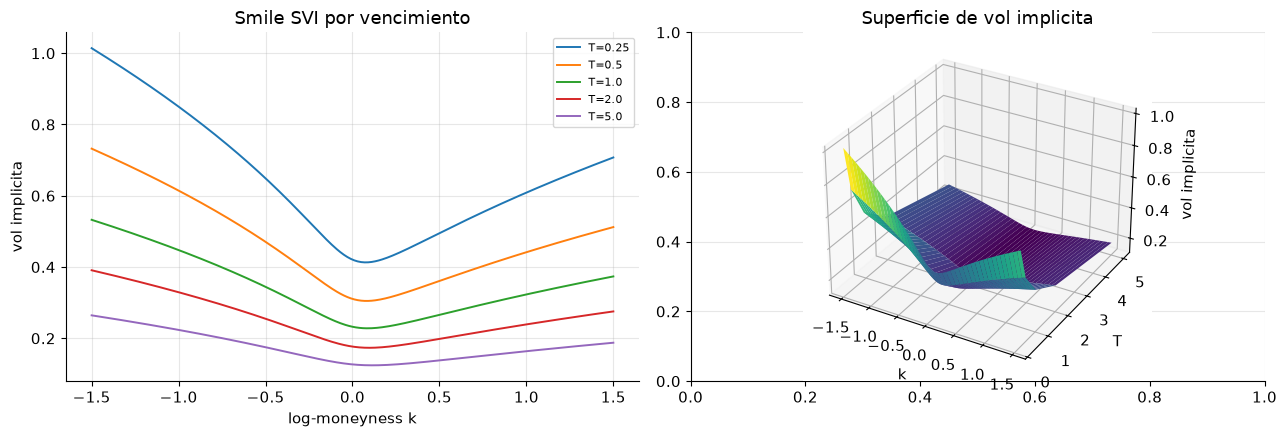

In [3]:
Ts = np.array([0.25, 0.5, 1.0, 2.0, 5.0])


def svi_params(T):
    '''Parametros SVI variando suavemente en T (Demo 1): construidos para NO violar calendario.'''
    a = 0.02 + 0.01 * np.sqrt(T)
    b = 0.10 + 0.02 * np.sqrt(T)
    rho = -0.4
    m = 0.0
    sigma = 0.15 + 0.05 * np.sqrt(T)
    return a, b, rho, m, sigma


W = np.zeros((len(Ts), len(k_grid)))
for i, T in enumerate(Ts):
    a, b, rho, m, sigma = svi_params(T)
    W[i, :] = svi_total_variance(k_grid, a=a, b=b, rho=rho, m=m, sigma=sigma)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for i, T in enumerate(Ts):
    axes[0].plot(k_grid, np.sqrt(W[i] / T), label=f"T={T}")
axes[0].set_xlabel("log-moneyness k"); axes[0].set_ylabel("vol implicita")
axes[0].set_title("Smile SVI por vencimiento"); axes[0].legend(fontsize=8)

ax3d = fig.add_subplot(1, 2, 2, projection="3d")
Kg, Tg = np.meshgrid(k_grid, Ts)
ax3d.plot_surface(Kg, Tg, np.sqrt(W / Tg), cmap="viridis")
ax3d.set_xlabel("k"); ax3d.set_ylabel("T"); ax3d.set_zlabel("vol implicita")
ax3d.set_title("Superficie de vol implicita")
fig.tight_layout(); plt.show()

### Demo 2 — verificación de calendario y butterfly sobre toda la malla

Verificamos numéricamente, sobre la superficie recién construida, que se cumplen las dos condiciones de la Sección 1: $w$ no decreciente en $T$ para cada $k$ (calendario), y $g(k)\ge0$ en cada vencimiento (butterfly, vía la condición de Durrleman) — las dos propiedades que garantizan que la superficie no admite arbitraje estático.

In [4]:
calendar_ok = np.all(np.diff(W, axis=0) >= -1e-10)
print(f"calendario (w no decreciente en T, para cada k): {calendar_ok}")

butterfly_ok_by_T = []
for T in Ts:
    a, b, rho, m, sigma = svi_params(T)
    w_func = lambda k, a=a, b=b, rho=rho, m=m, sigma=sigma: svi_total_variance(k, a=a, b=b, rho=rho, m=m, sigma=sigma)
    g = durrleman_g(k_grid[10:-10], w_func)
    ok = np.all(g >= -1e-6)
    butterfly_ok_by_T.append(ok)
    print(f"T={T}: butterfly (Durrleman g>=0) = {ok} (min g = {g.min():.4f})")

butterfly_ok = all(butterfly_ok_by_T)
print(f"\nbutterfly ok en todos los vencimientos: {butterfly_ok}")

calendario (w no decreciente en T, para cada k): True
T=0.25: butterfly (Durrleman g>=0) = True (min g = 0.2847)
T=0.5: butterfly (Durrleman g>=0) = True (min g = 0.2868)
T=1.0: butterfly (Durrleman g>=0) = True (min g = 0.2895)
T=2.0: butterfly (Durrleman g>=0) = True (min g = 0.2930)
T=5.0: butterfly (Durrleman g>=0) = True (min g = 0.2993)

butterfly ok en todos los vencimientos: True


### Demo 3 — control negativo: una superficie con calendario invertido debe fallar el chequeo

Construimos deliberadamente una superficie con el parámetro `a(T)` en el orden INVERSO (decreciente en $T$ en vez de creciente) — esto viola calendario a propósito. Si el chequeo de la Demo 2 está bien implementado, debe detectar esta violación (no basta con que pase superficies buenas; también tiene que rechazar las malas).

calendario en la superficie CON arbitraje intencional: False (debe ser False -- el chequeo SI detecta la violacion)


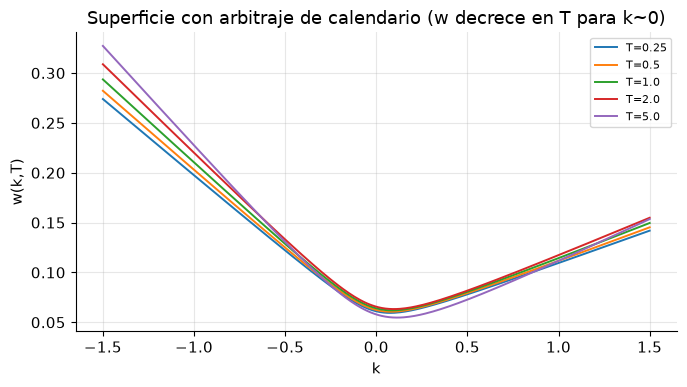

In [5]:
def svi_params_bad(T, T_max=5.0):
    '''Igual que svi_params pero con 'a' en orden INVERTIDO en T -- viola calendario a proposito.'''
    a = 0.02 + 0.01 * np.sqrt(T_max - T)
    b = 0.10 + 0.02 * np.sqrt(T)
    rho = -0.4
    m = 0.0
    sigma = 0.15 + 0.05 * np.sqrt(T)
    return a, b, rho, m, sigma


W_bad = np.zeros((len(Ts), len(k_grid)))
for i, T in enumerate(Ts):
    a, b, rho, m, sigma = svi_params_bad(T)
    W_bad[i, :] = svi_total_variance(k_grid, a=a, b=b, rho=rho, m=m, sigma=sigma)

calendar_bad_ok = np.all(np.diff(W_bad, axis=0) >= -1e-10)
print(f"calendario en la superficie CON arbitraje intencional: {calendar_bad_ok} "
      f"(debe ser False -- el chequeo SI detecta la violacion)")

fig, ax = plt.subplots(figsize=(7, 4))
for i, T in enumerate(Ts):
    ax.plot(k_grid, W_bad[i], label=f"T={T}")
ax.set_xlabel("k"); ax.set_ylabel("w(k,T)")
ax.set_title("Superficie con arbitraje de calendario (w decrece en T para k~0)")
ax.legend(fontsize=8); fig.tight_layout(); plt.show()

## 2. Calibración de SVI a un smile de mercado

Recuperar los parámetros SVI verdaderos a partir de precios: se genera un smile con
`svi_params` a un vencimiento fijo, se convierte a precios Black-Scholes, se invierte de
vuelta a vol implícita (control de round-trip: `implied_vol(bs_price(...))` debe
reproducir la vol de entrada a máquina-epsilon), y se recalibra SVI con mínimos cuadrados
sobre esas vols — sin ruido, el problema está exactamente identificado y debe recuperar
los 5 parámetros originales.

In [6]:
T_cal = 1.0
a_true, b_true, rho_true, m_true, sigma_true = svi_params(T_cal)
F0 = 100.0
strikes = F0 * np.exp(np.linspace(-0.6, 0.6, 15))
k_obs = np.log(strikes / F0)

w_true = svi_total_variance(k_obs, a=a_true, b=b_true, rho=rho_true, m=m_true, sigma=sigma_true)
iv_true = np.sqrt(w_true / T_cal)

prices = np.array([bs_price(F0, K, 0.0, 0.0, iv, T_cal, kind="call") for K, iv in zip(strikes, iv_true)])
iv_recovered = np.array([implied_vol(p, F0, K, 0.0, 0.0, T_cal, kind="call") for p, K in zip(prices, strikes)])
max_diff_roundtrip = np.max(np.abs(iv_recovered - iv_true))
print(f"round-trip precio->vol (debe ser ~0, maquina-epsilon): {max_diff_roundtrip:.2e}")


def resid_svi(params):
    a, b, rho, m, sigma = params
    if b < 0.0 or abs(rho) >= 1.0 or sigma <= 0.0:
        return np.full(len(k_obs), 1e3)
    w_model = svi_total_variance(k_obs, a=a, b=b, rho=rho, m=m, sigma=sigma)
    return np.sqrt(w_model / T_cal) - iv_recovered


fit = least_squares(resid_svi, x0=[0.01, 0.05, 0.0, 0.0, 0.3],
                     bounds=([-1.0, 0.0, -0.999, -2.0, 1e-4], [1.0, 2.0, 0.999, 2.0, 5.0]))
a_f, b_f, rho_f, m_f, sigma_f = fit.x
true_params = np.array([a_true, b_true, rho_true, m_true, sigma_true])
fit_params = fit.x
print(f"\nparametros verdaderos:   a={a_true:.5f}, b={b_true:.5f}, rho={rho_true:.5f}, m={m_true:.5f}, sigma={sigma_true:.5f}")
print(f"parametros recalibrados: a={a_f:.5f}, b={b_f:.5f}, rho={rho_f:.5f}, m={m_f:.5f}, sigma={sigma_f:.5f}")

# rel_err con denominador seguro (m_true=0 -- usar error absoluto ahi)
rel_err = np.array([
    abs(fit_params[i] - true_params[i]) / abs(true_params[i]) if abs(true_params[i]) > 1e-8
    else abs(fit_params[i] - true_params[i])
    for i in range(5)
])
print(f"\nerror relativo (absoluto para m, ~0): {np.round(rel_err, 6)}")

round-trip precio->vol (debe ser ~0, maquina-epsilon): 2.01e-13



parametros verdaderos:   a=0.03000, b=0.12000, rho=-0.40000, m=0.00000, sigma=0.20000
parametros recalibrados: a=0.03000, b=0.12000, rho=-0.40000, m=-0.00000, sigma=0.20000

error relativo (absoluto para m, ~0): [0. 0. 0. 0. 0.]


## 3. Validación

Cuatro chequeos: (1) y (2) la superficie arbitrage-free de la Demo 1 pasa calendario y butterfly en toda la malla; (3) la superficie con arbitraje intencional de la Demo 3 SÍ es detectada — una verificación negativa, tan importante como las positivas; (4) la recalibración de SVI de la Sección 2 recupera los 5 parámetros verdaderos dentro de 1% de error relativo.

In [7]:
check1 = calendar_ok
print(f"1. superficie arbitrage-free pasa calendario: {check1}")

check2 = butterfly_ok
print(f"2. superficie arbitrage-free pasa butterfly (Durrleman) en todos los vencimientos: {check2}")

check3 = not calendar_bad_ok
print(f"3. superficie CON arbitraje intencional SI es detectada (calendario falla): {check3}")

check4 = np.all(rel_err < 0.01)
print(f"4. recalibracion SVI recupera los 5 parametros dentro de rtol=1%: {check4} (max err={rel_err.max():.2e})")

assert check1
assert check2
assert check3
assert check4
print("\nValidacion completa: 4/4 dentro de tolerancia.")

1. superficie arbitrage-free pasa calendario: True
2. superficie arbitrage-free pasa butterfly (Durrleman) en todos los vencimientos: True
3. superficie CON arbitraje intencional SI es detectada (calendario falla): True
4. recalibracion SVI recupera los 5 parametros dentro de rtol=1%: True (max err=1.05e-08)

Validacion completa: 4/4 dentro de tolerancia.


## Referencias

- Gatheral, J. (2004). *A parsimonious arbitrage-free implied volatility
  parameterization with application to the valuation of volatility derivatives*.
- Gatheral, J. & Jacquier, A. (2014). *Arbitrage-free SVI volatility surfaces*.
  Quantitative Finance, 14(1), 59-71.